In [119]:
import pandas as pd
import polars as pl
import seaborn as sns
import numpy as np
from datacommons_client.client import DataCommonsClient

In [167]:
client = DataCommonsClient(dc_instance="datacommons.one.org")

Notes:

- We will likely have underrepresentation of WDBs that are in areas with smaller populations since the WIOA data does not report the WBD code when their are less than 50 participants.


In [93]:
dict_workforce_boards = {}
dict_workforce_boards[2023] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2023.xlsx", skiprows=8)
dict_workforce_boards[2022] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2022.xlsx", skiprows=8)
dict_workforce_boards[2021] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2021.xlsx", skiprows=8)
dict_workforce_boards[2020] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2020.xlsx", skiprows=8)
dict_workforce_boards[2019] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2019.xlsx", skiprows=8)
dict_workforce_boards[2018] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2018.xlsx", skiprows=8)
dict_workforce_boards[2017] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2017.xlsx", skiprows=8)
dict_workforce_boards[2016] = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2016.xlsx", skiprows=8)

In [ ]:
# For Program Years 2015 an earlier, the format of the Workforce Board Reporting Codes differs. In particular,
# PY2012 - PY2014, do not have a Jurisdiction Name and therefore are not included in this analysis.

df_wdb2015 = pd.read_excel("../data/raw/workforce_development_board_codes/wdb_codes_2015.xlsx", skiprows=1)

# We remove unnecessary header rows which include state name and "ETA Assigned Code"
indices_to_remove = df_wdb2015[df_wdb2015["ETA Assigned Code"] == "ETA Assigned Code"].index
indices_to_remove = indices_to_remove.append(indices_to_remove - 1)
df_wdb2015 = df_wdb2015.drop(indices_to_remove).reset_index(drop=True)

# Rename columns to match earlier program years
df_wdb2015 = df_wdb2015.rename(columns={
    "ETA Assigned Code": "ETA Code",
    "Local Board Name": "Local Board Name",
    "Local Jurisdiction Name": "Jurisdiction Name"
})

df_wdb2015["ETA Code"] = df_wdb2015["ETA Code"].astype(int)

df_wdb2015["Program Year"] = 2015

dict_workforce_boards[2015] = df_wdb2015

In [148]:
df_workforce_boards = pd.concat(dict_workforce_boards.values())

# Remove entries that are deactivated or pending deactivation
is_status_active = df_workforce_boards["Status"].isin(["Approved", "Edit-Pending Approval"])

df_workforce_boards = df_workforce_boards[is_status_active].copy()

df_workforce_boards = df_workforce_boards.rename(columns={
    "Program Year": "program_year",
    "Region": "region",
    "State/Territory": "state",
    "ETA Code": "workforce_board_code",
    "Local Board Name": "local_board",
    "Jurisdiction Name": "jurisdiction"
}).drop(columns=["Created Timestamp", "Modified Timestamp", "Status"])

In [154]:
# Determine if the jurisdiction of workforce boards is changing between program years

df_workforce_boards = df_workforce_boards.sort_values(by=["jurisdiction"], ascending=True)

df_workforce_boards_grouped = df_workforce_boards.groupby(by=["program_year", "state", "workforce_board_code"])["jurisdiction"].apply(tuple).reset_index()

df_workforce_boards_grouped = df_workforce_boards_grouped.sort_values(by=["program_year", "state"], ascending=False)

# Remove duplicates that repeat across program years if they cover the same jurisdiction
df_workforce_boards_grouped = df_workforce_boards_grouped[~df_workforce_boards_grouped.duplicated(subset=["workforce_board_code", "state", "jurisdiction"])].reset_index(drop=True)

<Axes: xlabel='program_year', ylabel='count'>

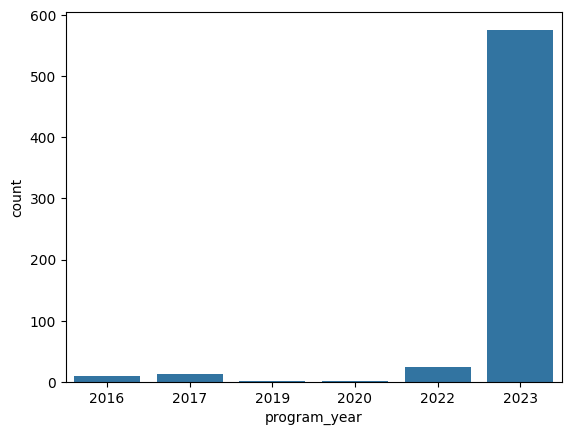

In [169]:
sns.barplot(df_workforce_boards_grouped["program_year"].value_counts().sort_index())

In [ ]:
sns.histplot(df_workforce_boards[2023].groupby(by=["ETA Code"])["Jurisdiction Name"].nunique(), discrete=True)

In [259]:
df_workforce_boards_grouped[df_workforce_boards_grouped["state"] == "Alaska"].jurisdiction

566    (Aleutians East Borough, Aleutians West Boroug...
567                  (Anchorage/Mat-Su Economic Region,)
568    (Gulf Coast Economic Region, Interior Economic...
602    (Aleutians West Borough, Bethel Borough, Brist...
Name: jurisdiction, dtype: object

<Axes: xlabel='jurisdiction', ylabel='Count'>

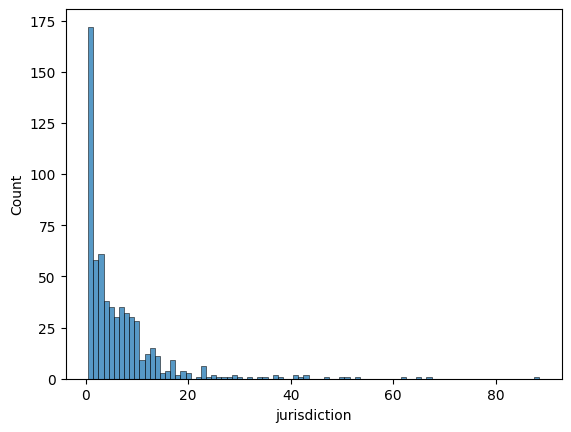

In [173]:
sns.histplot(df_workforce_boards_grouped["jurisdiction"].apply(len), discrete=True)

In [222]:
# Need to determine how many jurisdictions are counties or something else

df_workforce_boards_filtered = df_workforce_boards_grouped.explode("jurisdiction")
df_workforce_boards_filtered["jurisdiction_state"] = df_workforce_boards_filtered["jurisdiction"] + ", " + df_workforce_boards_filtered["state"]

In [235]:
place_names = df_workforce_boards_filtered["jurisdiction_state"].unique()

In [236]:
place_names

array(['Albany County, Wyoming', 'Big Horn County, Wyoming',
       'Campbell County, Wyoming', ..., 'De Kalb County, Tennessee',
       'Nashville City/Davidson County, Tennessee',
       'Mc Nairy County, Tennessee'], shape=(3975,), dtype=object)

In [239]:
county_names = ('Medina County, Ohio', 'Summit County, Ohio', 'Alexandria City, Virginia', 'Southeast Fairbanks Borough, Alaska')

places = client.resolve.fetch_dcids_by_name(place_names).to_flat_dict()

# Extract just the DCIDs
dcids = [places[name] for name in place_names if isinstance(places[name], str)]

In [255]:
client.resolve.fetch_dcids_by_name(['Hamilton, Iowa']).to_flat_dict()

FlatCandidateMapping({'Hamilton, Iowa': ['geoId/19079', 'geoId/1933870']})

In [261]:
manual_dcids = {
    'St. Croix Island, Virgin Islands': "geoId/78010",
    'Austin City, Less Austin City Part In Williamson County, Texas': "geoId/4805000",
    'Balance Of Collin County Less Dallas City Part, Texas': "geoId/48085",
    'Balance Of Denton County Less Dallas City Part, Texas': "geoId/48121",
    'New Shoreham Town, Rhode Island': "geoId/4450500",
    'Lares Municipio, Puerto Rico': "geoId/72081",
    'Hormigueros Municipio, Puerto Rico': "geoId/72067",
    'Canovas Municipio, Puerto Rico': None,
    'Luquillo Municipio, Puerto Rico': "geoId/72089",
    'Toa Baja Municipio, Puerto Rico': "geoId/72137",
    'Bayamon Municipio, Puerto Rico': "geoId/72021",
    'Arroyo Municipio, Puerto Rico': "geoId/72015",
    'Balance Of Clackamas County Less Portland City, Oregon': "geoId/41005",
    'Franklin County (Including The City Of Columbus), Ohio': "geoId/39049",
    'Mahoning County Less Youngstown City, Ohio': "geoId/39099",
    'Summit County Including City Of Akron, Ohio': "geoId/39153",
    'Hempstead Town In Nassau County, New York': "geoId/3634000",
    'Hempstead Town, New York': "geoId/3634000",
    'Essex County Less Newark City, New Jersey': "geoId/34013",
    'Div. E & T Tradereadjustact, New Jersey': None,
    'Famis Stateside, New Jersey': None,
    'Nj Trenton Central Office, New Jersey': None,
    'Response Team, New Jersey': None,
    'Ui Statewide, New Jersey': None,
    'Workfirst Operations, New Jersey': None,
    'Carson City, Nevada': "geoId/3209700",
    'Balance Of St. Louis County Less Duluth City, Minnesota': "geoId/27137",
    'Balance Of Hennepin County Less Minneapolis City, Minnesota': "geoId/27053",
    'Upper Peninsula, Michigan': None,
    'Central Upper Peninsula, Michigan': None,
    'Dighton Town, Massachusetts': "geoId/2516950",
    'Hin25055Le Town, Massachusetts': None,
    'Windsor Town, Massachusetts': "geoId/2580685",
    'Wenham Town, Massachusetts': "wikidataId/Q2418343",
    'Carver Town, Massachusetts': "wikidataId/Q372315",
    'Shutesbury Town, Massachusetts': "geoId/2561905",
    'Balance Of Bossier Parish Less Shreveport City, Louisiana': "geoId/22015",
    'Balance Of Caddo Parish Less Shreveport City, Louisiana': "geoId/22015",
    'Terrebonne Consortium, Louisiana': "geoId/22109",
    'Kentucky Statewide, Kentucky': None,
    'Adair, Iowa': "geoId/19001",
    'Audubon, Iowa': "geoId/19009",
    'Cherokee, Iowa': "geoId/19035",
    'Fremont, Iowa': "geoId/19071",
    'Greene, Iowa': "geoId/19073",
    'Hamilton, Iowa': "geoId/19079",
    'Humboldt, Iowa': "geoId/19091",
    'Monona, Iowa': "geoId/19133",
    'Osceola, Iowa': "geoId/19143",
    'Plymouth, Iowa': "geoId/19149",
    'Pocahontas, Iowa': "geoId/19151",
    'Shelby, Iowa': "geoId/19165",
    'Union, Iowa': "geoId/19175",
    'Balance Of Du Page Co Less Chicago City, Illinois': "geoId/17043",
    'Balance Of Cook Co Less:, Illinois': "geoId/17031",
    'Hanover Township, Illinois': "geoId/1732694",
    'Maine Township, Illinois': "geoId/1746162",
    'Newtown Town, Connecticut': "geoId/0952980",
    'Contra Costa County Less Richmond City, California': "geoId/06013",
    'Alameda County Less Oakland City, California': "geoId/06001",
    'Lakewood City, California': "geoId/0639892",
    'Balance Of Pulaski County Less Little Rock City, Arkansas': "geoId/05119",
    'Camp Verde Reservation, Arizona': None,
    'Hualapai Reservation, Arizona': None,
    'Yavapai Reservation, Arizona': None,
    'Balance Of Gila County Less, Arizona': "geoId/04007",
    'Balance Of Pinal County Less, Arizona': "geoId/04021",
    'Maricopa Reservation, Arizona': None,
    'Maricopa Reservation In Pinal County, Arizona': None,
    'Papago Reservation, Arizona': None,
    'Payson Community Of Yavapai-Apache, Arizona': None,
    'Camp Verde Reservation In Yavapai County, Arizona': None,
    'Fort Mc Dowell Reservation In Maricopa County, Arizona': None,
    'Hualapai Reservation In Coconino County, Arizona': None,
    'Papago Reservation In Maricopa County, Arizona': None,
    'Pascua Yaqui Reservation, Arizona': None,
    'Pascua Yaqui Reservation In Pima County, Arizona': None,
    'Payson Community Of Yavapai-Apache In Gila County, Arizona': None,
    'Salt River Reservation, Arizona': None,
    'Salt River Reservation In Maricopa County, Arizona': None,
    'Yavapai Reservation In Yavapai County, Arizona': None,
    'Fort Mc Dowell Reservation, Arizona': None,
    'Rose Island, American Samoa': None,
    'Wade Hampton Borough, Alaska': None,
    'Anchorage/Mat-Su Economic Region, Alaska': "geoId/02020",
    'Gulf Coast Economic Region, Alaska': None,
    'Interior Economic Region, Alaska': None,
    'Northern Economic Region, Alaska': None,
    'Southeast Economic Region, Alaska': None,
    'Southwest Economic Region, Alaska': None,
    'Hudson County Less Jersey City, New Jersey': "geoId/34017"
}

In [250]:
[name for name in place_names if not isinstance(places[name], str)]

['St. Croix Island, Virgin Islands',
 'Austin City, Less Austin City Part In Williamson County, Texas',
 'Balance Of Collin County Less Dallas City Part, Texas',
 'Balance Of Denton County Less Dallas City Part, Texas',
 'New Shoreham Town, Rhode Island',
 'Lares Municipio, Puerto Rico',
 'Hormigueros Municipio, Puerto Rico',
 'Canovas Municipio, Puerto Rico',
 'Luquillo Municipio, Puerto Rico',
 'Toa Baja Municipio, Puerto Rico',
 'Bayamon Municipio, Puerto Rico',
 'Arroyo Municipio, Puerto Rico',
 'Balance Of Clackamas County Less Portland City, Oregon',
 'Franklin County (Including The City Of Columbus), Ohio',
 'Mahoning County Less Youngstown City, Ohio',
 'Summit County Including City Of Akron, Ohio',
 'Hempstead Town In Nassau County, New York',
 'Hempstead Town, New York',
 'Essex County Less Newark City, New Jersey',
 'Div. E & T Tradereadjustact, New Jersey',
 'Famis Stateside, New Jersey',
 'Nj Trenton Central Office, New Jersey',
 'Response Team, New Jersey',
 'Ui Statewide

In [256]:
county_dcids = ["wikidataId/Q372315"]
df_county = client.observations_dataframe(entity_dcids=county_dcids, variable_dcids=['Count_Person', 'Median_Age_Person', 'Median_Income_Person'], date='latest')

In [257]:
df_county

,date,entity,entity_name,variable,variable_name,facetId,importName,measurementMethod,observationPeriod,provenanceUrl,unit,value
0,2018,wikidataId/Q372315,Carver,Count_Person,Total population,2517965213,CensusPEP,CensusPEPSurvey,None,https://www.census.gov/programs-surveys/popest...,None,11777.0


In [16]:
lf = pl.scan_parquet("../data/processed/wioa_data_filtered.parquet")

In [20]:
df = (
    lf.select(
        pl.col("workforce_board_code_1").unique()
    )
    .collect()
)

In [49]:
eta_codes = set(df_workforce_boards["eta_code"].unique())
workforce_board_codes = set(df["workforce_board_code_1"].unique())

In [35]:
df.merge(df_workforce_boards, left_on="workforce_board_code_1", right_on="eta_code", how="inner")

,workforce_board_code_1,program_year,region,state,eta_code,local_board_name,jurisdiction_name,created_timestamp,modified_timestamp,status
0,36230,2023,Region 1,New York,36230,Dutchess County,Dutchess County,01-Jun-2023,NaN,Approved
1,34010,2023,Region 1,New Jersey,34010,Union County Workforce Investment Board,Union County,01-Jun-2023,NaN,Approved
2,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Floyd County,01-Jun-2023,NaN,Approved
3,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Lynn County,01-Jun-2023,NaN,Approved
4,48245,2023,Region 4,Texas,48245,South Plains Workforce Development Board,Bailey County,01-Jun-2023,NaN,Approved
...,...,...,...,...,...,...,...,...,...,...
1892,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Polk County,01-Jun-2023,NaN,Approved
1893,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Dunn County,01-Jun-2023,NaN,Approved
1894,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Pierce County,01-Jun-2023,NaN,Approved
1895,55065,2023,Region 5,Wisconsin,55065,West Central Wisconsin Workforce Development B...,Clark County,01-Jun-2023,NaN,Approved


In [5]:
df['jurisdiction_state'] = df.apply(lambda x : x["jurisdiction_name"] + ', ' + x["state"] , axis=1)

In [6]:
county_names = df['jurisdiction_state'].unique()

In [ ]:
# Fetch the corresponding DCIDs for the juristictions
counties = client.resolve.fetch_dcids_by_name(county_names).to_flat_dict()

In [35]:
# Extract just the DCIDs
county_dcids = [counties[county_name] for county_name in county_names if isinstance(counties[county_name], str)]

In [39]:
len(county_dcids)

3872

In [36]:
df_county = client.observations_dataframe(entity_dcids=county_dcids, variable_dcids=['Count_Person', 'Median_Age_Person', 'Median_Income_Person'], date='latest')

In [37]:
df_county

,date,entity,entity_name,variable,variable_name,facetId,importName,measurementMethod,observationPeriod,provenanceUrl,unit,value
0,2024,geoId/28095,Monroe County,Count_Person,Total population,2176550201,USCensusPEP_Annual_Population,CensusPEPSurvey,P1Y,https://www.census.gov/programs-surveys/popest...,None,33483.0
1,2023,geoId/28095,Monroe County,Count_Person,Total population,1145703171,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,None,33928.0
2,2020,geoId/28095,Monroe County,Count_Person,Total population,1541763368,USDecennialCensus_RedistrictingRelease,USDecennialCensus,None,https://www.census.gov/programs-surveys/decenn...,None,34180.0
3,2024,geoId/28095,Monroe County,Count_Person,Total population,2390551605,USCensusPEP_AgeSexRaceHispanicOrigin,CensusPEPSurvey_Race2000Onwards,P1Y,https://www2.census.gov/programs-surveys/popes...,None,33483.0
4,2023,geoId/28095,Monroe County,Count_Person,Total population,1964317807,CensusACS5YearSurvey_SubjectTables_S0101,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/table?q=S0101:+Age+and...,None,33928.0
...,...,...,...,...,...,...,...,...,...,...,...,...
42719,2023,geoId/48065,Carson County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,42308.0
42720,2023,geoId/53057,Skagit County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,42170.0
42721,2023,geoId/53057,Skagit County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,42170.0
42722,2023,geoId/13121,Fulton County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,50463.0


In [24]:
df_county[df_county["variable"] == "Median_Income_Person"]

,date,entity,entity_name,variable,variable_name,facetId,importName,measurementMethod,observationPeriod,provenanceUrl,unit,value
64,2023,geoId/01117,Shelby County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,46566.0
65,2023,geoId/01117,Shelby County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,46566.0
66,2023,geoId/01073,Jefferson County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,35600.0
67,2023,geoId/01073,Jefferson County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,35600.0
68,2023,geoId/01127,Walker County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,29524.0
69,2023,geoId/01127,Walker County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,29524.0
70,2023,geoId/01021,Chilton County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,31816.0
71,2023,geoId/01021,Chilton County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,31816.0
72,2023,geoId/01115,St. Clair County,Median_Income_Person,Median Income of a Population,1305418269,CensusACS5YearSurvey,CensusACS5yrSurvey,None,https://www.census.gov/programs-surveys/acs/da...,USDollar,37446.0
73,2023,geoId/01115,St. Clair County,Median_Income_Person,Median Income of a Population,3214767095,CensusACS5YearSurvey_SubjectTables_S0701,CensusACS5yrSurveySubjectTable,None,https://data.census.gov/cedsci/table?q=S0701&t...,USDollar,37446.0


In [ ]:
df.to_csv("data/processed/workforce_boards.csv")